Preprocessing + Data Loading (Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/diabetic-retinopathy-dataset.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Extraction done")

Extraction done


In [ ]:
import os
print(os.listdir('/content/data'))

['Moderate DR', 'Mild DR', 'Healthy', 'Severe DR', 'Proliferate DR']


In [ ]:
data_path = "/content/data"

In [ ]:
import os

rename_map = {
    "Mild DR": "Mild",
    "Moderate DR": "Moderate",
    "Severe DR": "Severe",
    "Proliferate DR": "Proliferative"
}

for old, new in rename_map.items():
    old_path = os.path.join(data_path, old)
    new_path = os.path.join(data_path, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print(os.listdir(data_path))

['Mild', 'Moderate', 'Healthy', 'Proliferative', 'Severe']


In [ ]:
##Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
##Create Data Generator
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [ ]:
##Load Training Data
train_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 2200 images belonging to 5 classes.


In [ ]:
##Load Validation Data
val_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 550 images belonging to 5 classes.


In [ ]:
print(train_data.class_indices)

{'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Proliferative': 3, 'Severe': 4}


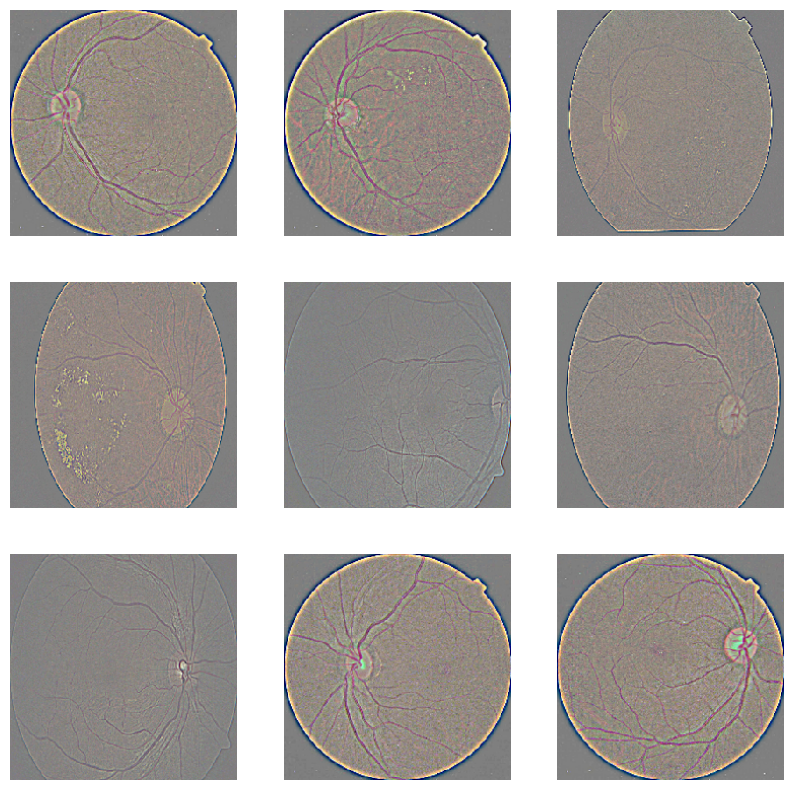

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

building CNN Baseline Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 278ms/step - accuracy: 0.5600 - loss: 1.2966 - val_accuracy: 0.6273 - val_loss: 0.9806
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.6477 - loss: 0.9839 - val_accuracy: 0.6691 - val_loss: 0.9187
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.6500 - loss: 0.9472 - val_accuracy: 0.6818 - val_loss: 0.8808
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.6605 - loss: 0.9216 - val_accuracy: 0.6800 - val_loss: 0.9340
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.6573 - loss: 0.9120 - val_accuracy: 0.6818 - val_loss: 0.8642


In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_data)

print("Training Accuracy:", train_accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.6914 - loss: 0.8204
Training Accuracy: 0.6913636326789856


In [ ]:
val_loss, val_accuracy = cnn_model.evaluate(val_data)

print("Validation Accuracy:", val_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6818 - loss: 0.8642 
Validation Accuracy: 0.6818181872367859


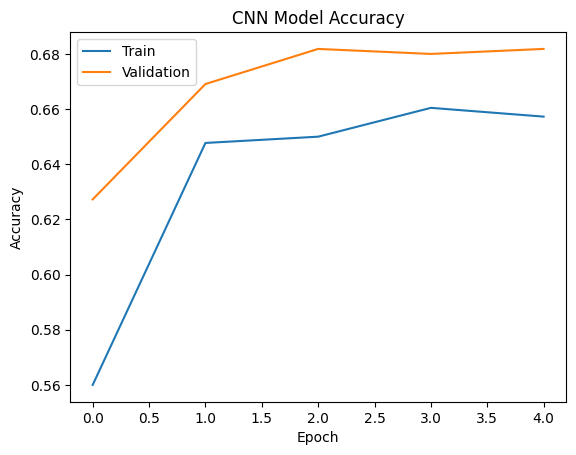

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

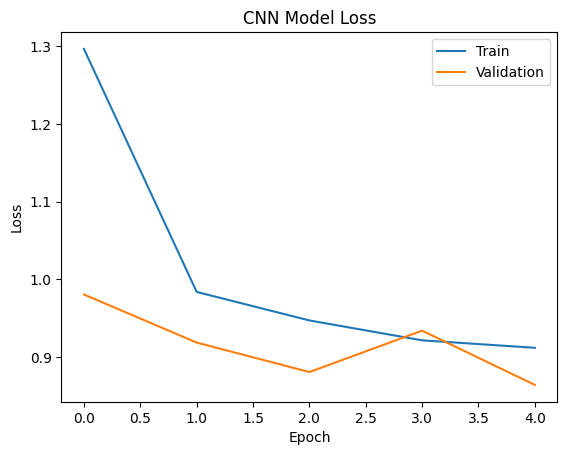

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

cNN Evaluation

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

In [ ]:
predictions = cnn_model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step


In [ ]:
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

In [ ]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

               precision    recall  f1-score   support

      Healthy       0.36      0.40      0.38       200
         Mild       0.07      0.05      0.06        74
     Moderate       0.33      0.47      0.39       180
Proliferative       0.00      0.00      0.00        58
       Severe       0.05      0.03      0.03        38

     accuracy                           0.31       550
    macro avg       0.16      0.19      0.17       550
 weighted avg       0.25      0.31      0.28       550



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[80 29 84  0  7]
 [27  4 39  0  4]
 [74 16 84  0  6]
 [24  5 25  0  4]
 [16  2 19  0  1]]


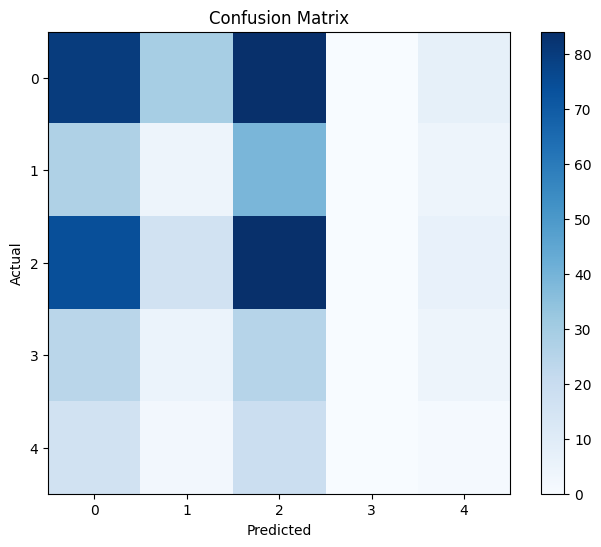

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
wrong_predictions = np.where(predicted_classes != true_classes)[0]

print("Total Wrong Predictions:", len(wrong_predictions))

Total Wrong Predictions: 381


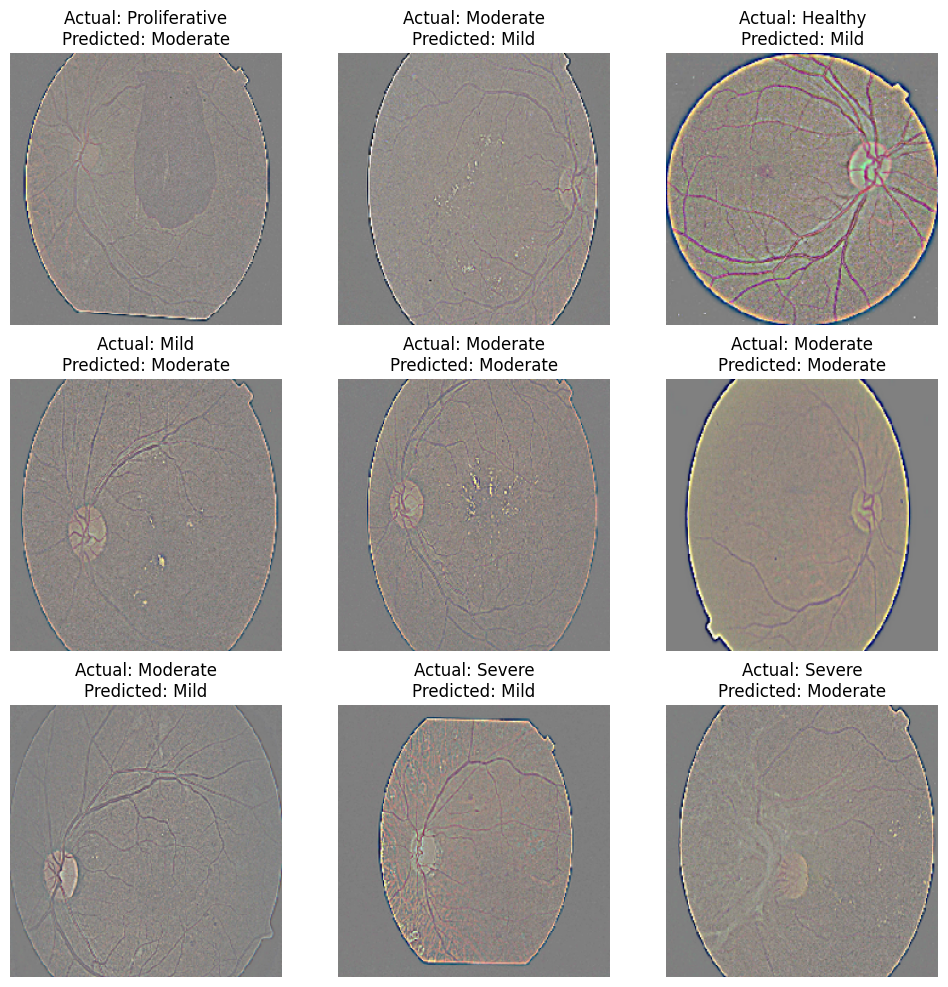

In [ ]:
plt.figure(figsize=(12,12))

for i, index in enumerate(wrong_predictions[:9]):

    image, label = val_data[index]

    plt.subplot(3,3,i+1)

    plt.imshow(image[0])

    actual_label = class_labels[np.argmax(label[0])]
    predicted_label = class_labels[predicted_classes[index]]

    plt.title("Actual: " + actual_label + "\nPredicted: " + predicted_label)

    plt.axis('off')

plt.show()

creating

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

In [ ]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in resnet_base.layers:
    layer.trainable = False

In [ ]:
resnet_model = Sequential([

    resnet_base,

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(5, activation='softmax')
])

In [ ]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,433,541 (138.98 MB)

 Trainable params: 12,845,829 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
resnet_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 377ms/step - accuracy: 0.4632 - loss: 2.4960 - val_accuracy: 0.6055 - val_loss: 1.2231
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.5341 - loss: 1.3161 - val_accuracy: 0.5873 - val_loss: 1.1737
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.5023 - loss: 1.3321 - val_accuracy: 0.6109 - val_loss: 1.1652
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.4905 - loss: 1.3447 - val_accuracy: 0.5745 - val_loss: 1.2678
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.5100 - loss: 1.3134 - val_accuracy: 0.6109 - val_loss: 1.1483


In [ ]:
train_loss, train_accuracy = resnet_model.evaluate(train_data)

print("Training Accuracy:", train_accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.5868 - loss: 1.1819
Training Accuracy: 0.5868181586265564


In [ ]:
val_loss, val_accuracy = resnet_model.evaluate(val_data)

print("Validation Accuracy:", val_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.6109 - loss: 1.1483
Validation Accuracy: 0.610909104347229


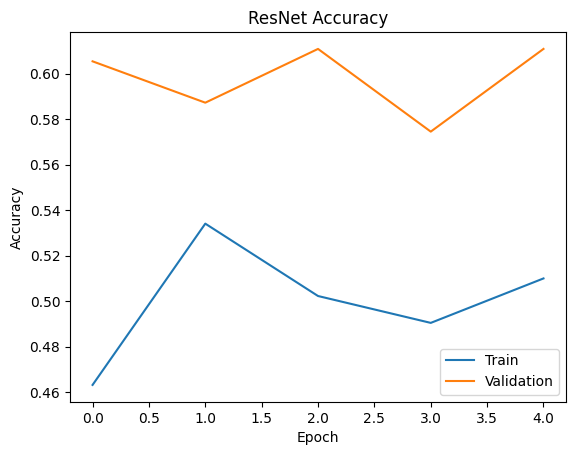

In [ ]:
plt.plot(resnet_history.history['accuracy'])
plt.plot(resnet_history.history['val_accuracy'])

plt.title('ResNet Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

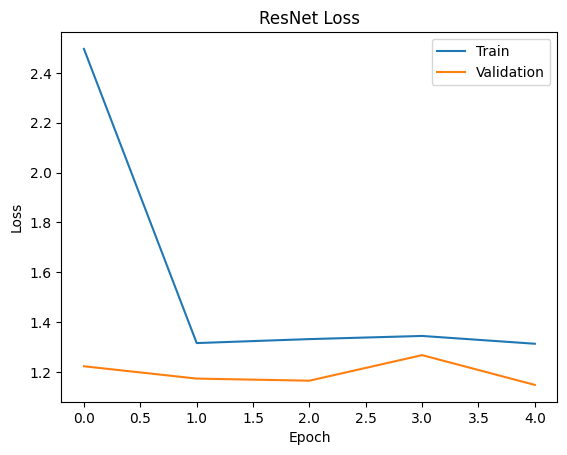

In [ ]:
plt.plot(resnet_history.history['loss'])
plt.plot(resnet_history.history['val_loss'])

plt.title('ResNet Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
resnet_predictions = resnet_model.predict(val_data)

resnet_predicted_classes = np.argmax(resnet_predictions, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 354ms/step


In [ ]:
print(classification_report(
    true_classes,
    resnet_predicted_classes,
    target_names=class_labels
))

               precision    recall  f1-score   support

      Healthy       0.38      0.34      0.36       200
         Mild       0.00      0.00      0.00        74
     Moderate       0.33      0.67      0.44       180
Proliferative       0.00      0.00      0.00        58
       Severe       0.00      0.00      0.00        38

     accuracy                           0.34       550
    macro avg       0.14      0.20      0.16       550
 weighted avg       0.25      0.34      0.27       550



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
resnet_cm = confusion_matrix(
    true_classes,
    resnet_predicted_classes
)

print(resnet_cm)

[[ 69   0 131   0   0]
 [ 22   0  52   0   0]
 [ 60   0 120   0   0]
 [ 17   0  41   0   0]
 [ 13   0  25   0   0]]


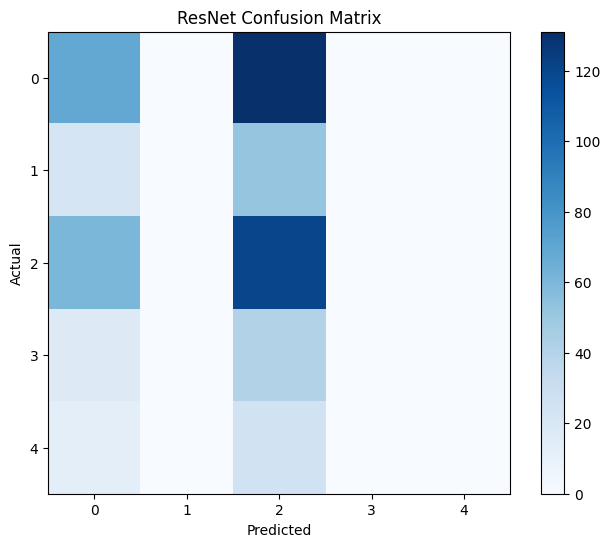

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(resnet_cm, cmap='Blues')

plt.title("ResNet Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## model comparison

In [ ]:
cnn_accuracy = history.history['val_accuracy'][-1]

resnet_accuracy = resnet_history.history['val_accuracy'][-1]

print("CNN Validation Accuracy:", cnn_accuracy)

print("ResNet Validation Accuracy:", resnet_accuracy)

CNN Validation Accuracy: 0.6818181872367859
ResNet Validation Accuracy: 0.610909104347229


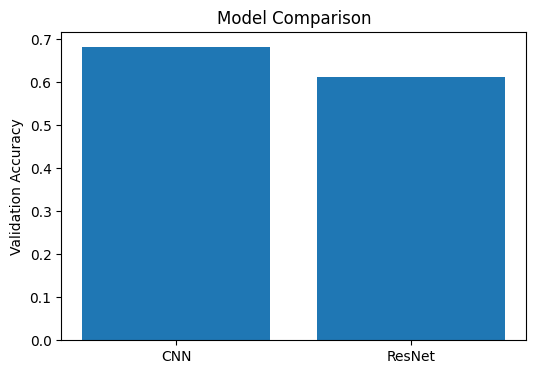

In [ ]:
models = ['CNN', 'ResNet']

accuracies = [cnn_accuracy, resnet_accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title('Model Comparison')

plt.ylabel('Validation Accuracy')

plt.show()

In [ ]:
if resnet_accuracy > cnn_accuracy:
    print("ResNet performed better than CNN")
else:
    print("CNN performed better than ResNet")

CNN performed better than ResNet


In [ ]:
wrong_predictions_resnet = np.where(
    resnet_predicted_classes != true_classes
)[0]

print("Total Wrong Predictions:", len(wrong_predictions_resnet))

Total Wrong Predictions: 361


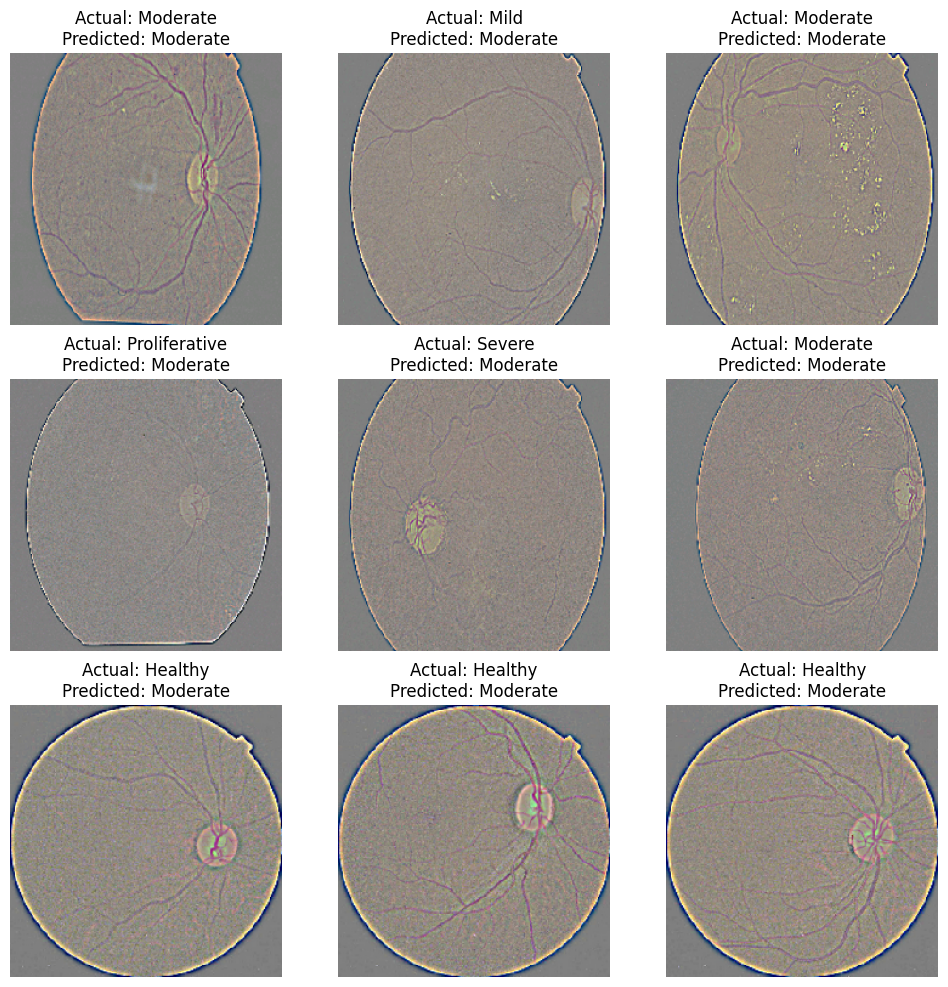

In [ ]:
plt.figure(figsize=(12,12))

for i, index in enumerate(wrong_predictions_resnet[:9]):

    image, label = val_data[index]

    plt.subplot(3,3,i+1)

    plt.imshow(image[0])

    actual_label = class_labels[np.argmax(label[0])]

    predicted_label = class_labels[
        resnet_predicted_classes[index]
    ]

    plt.title(
        "Actual: " + actual_label +
        "\nPredicted: " + predicted_label
    )

    plt.axis('off')

plt.show()

In [ ]:
cnn_model.save("cnn_model.h5")

resnet_model.save("resnet_model.h5")

print("Models saved successfully")

Models saved successfully


In [ ]:
if cnn_accuracy > resnet_accuracy:

    print("CNN performed better than ResNet in this experiment.")

    print()

    print("Possible reasons:")

    print("- Small dataset size")

    print("- Limited epochs for ResNet training")

    print("- Frozen pretrained layers")

    print("- CNN adapted better to current dataset")

else:

    print("ResNet performed better than CNN.")

    print()

    print("Transfer learning improved performance.")

CNN performed better than ResNet in this experiment.

Possible reasons:
- Small dataset size
- Limited epochs for ResNet training
- Frozen pretrained layers
- CNN adapted better to current dataset
